In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

## Bar chart - Counts of Job Postings

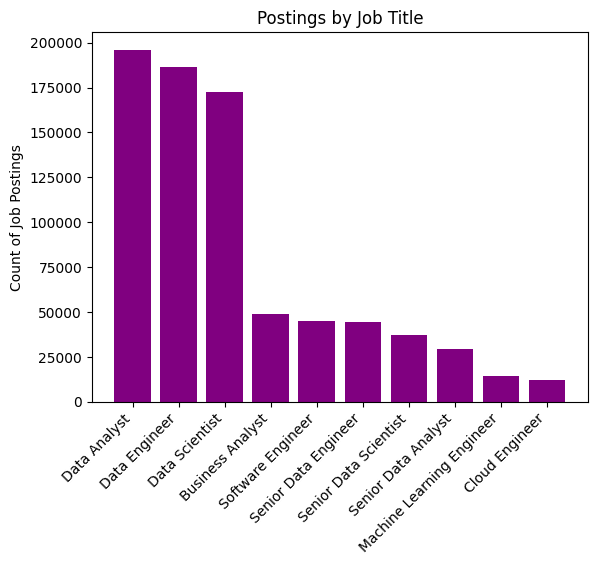

In [16]:
job_postings_count = df["job_title_short"].value_counts()

plt.bar(job_postings_count.index, job_postings_count.values, color="purple")
plt.title("Postings by Job Title")
plt.ylabel("Count of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.show()

In [23]:
senior_job_postings = df.loc[
    (df["job_title_short"].str.contains("senior", case=False)) & (df["salary_year_avg"].notna()),
    :
].reset_index()

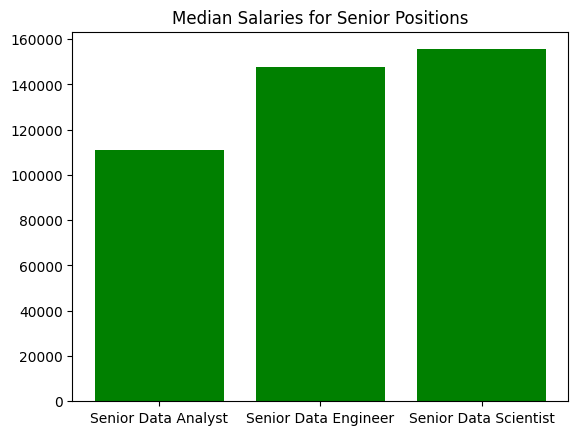

In [49]:
senior_job_salaries = senior_job_postings.groupby("job_title_short").agg(
    median_yearly_salary=("salary_year_avg", "median")
)

senior_job_salaries

plt.bar(senior_job_salaries.index, senior_job_salaries["median_yearly_salary"], color="Green")
plt.title("Median Salaries for Senior Positions")
plt.show()

In [60]:
brazilian_jobs_wfh = df.loc[
    df["search_location"] == "Brazil",
    ["job_work_from_home", "search_location"]
].reset_index(drop=True)

brazilian_jobs_wfh


,job_work_from_home,search_location
0,False,Brazil
1,False,Brazil
2,False,Brazil
3,True,Brazil
4,False,Brazil
...,...,...
7027,False,Brazil
7028,False,Brazil
7029,False,Brazil
7030,False,Brazil


In [64]:
brazilian_jobs_wfh_count = brazilian_jobs_wfh.groupby("job_work_from_home").agg(
    job_count=("search_location", "count")
)

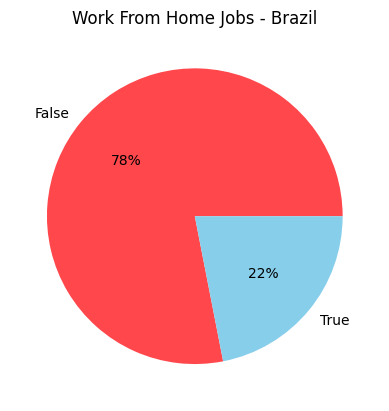

In [79]:
colors = ["xkcd:light red", "skyblue"]

plt.pie(brazilian_jobs_wfh_count["job_count"], labels=brazilian_jobs_wfh_count.index, colors=colors, autopct="%1.0f%%")
plt.title("Work From Home Jobs - Brazil")
plt.show()